In [1]:
from IPython.core.display import HTML
import pandas as pd

css = """
<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@4.0.0/dist/css/bootstrap.min.css" integrity="sha384-Gn5384xqQ1aoWXA+058RXPxPg6fy4IWvTNh0E263XmFcJlSAwiGgFAW/dAiS6JXm" crossorigin="anonymous">
<style type=\"text/css\">
#abTesting table,#abTesting .table {
    color: #333;
    font-family: unset;
    font-size: 12px;
    line-height: 1.5;
    width: 90vw;
    border-collapse:
    collapse; 
    border-spacing: 0;
    font-family: "SF Pro SC", "SF Pro Text", "SF Pro Icons", "PingFang SC", "Helvetica Neue", "Helvetica", "Arial", sans-serif;
}

body{
    padding-left: 2rem;
    padding-top: 1vh;
}

tr{
    border-bottom: 1px solid #C1C3D1;
}

tr:nth-child(even) {
    background-color: #F8F8F8;
}

#abTesting td, #abTesting th {
    /* border: 1px solid transparent; No more visible border */
    height: 30px;
    padding: 0.5rem;
}

#abTesting table tbody td,#abTesting .table tbody td{
    padding: 0.1rem .75rem;
    vertical-align: middle;
}

th {
    background-color: #DFDFDF; /* Darken header a bit */
    font-weight: bolder;
    font-size: larger;
    color: #000;
    text-align: center;
}
</style>
"""


def display_p_value_below_005(row: pd.Series, p_value_col_name: str = "p_value"):
    p_value = row[p_value_col_name]
    color = "black"
    if p_value is not None and p_value <= 0.05:
        color = "red"
    return f"""<span style='font-weight:bolder;color:{color};'>{p_value}</span>"""


def display_diff_to_v1(row: pd.Series, metric: str = "diff_to_v1%"):
    diff = row[metric]
    color = "green"
    if diff is not None and float(diff) > 0.0:
        color = "red"
    return f"""<span style='font-weight:bolder;color:{color};'>{diff:.4f} %</span>"""


def dataframe_to_html(df: pd.DataFrame, title: str):
    df_to_display = df.copy()

    df_to_display["p_value"] = df_to_display.apply(display_p_value_below_005, axis=1)
    df_to_display["diff_to_v1%"] = df_to_display.apply(display_diff_to_v1, axis=1)

    html_df = df_to_display.to_html(
        escape=False, index=False, classes="table dataframe"
    )
    html_content = f"""<html><head><meta charset="UTF-8">
    <meta name="title" content="{title}">
    {css}
    </head><body>
    <h2>{title}</h2>
    <h4>当P-value <= 0.05时表示实验结果统计学显著</h4>
    <span>统计学显著时，既可能表示该试验组是好于对照组，也可能是坏于对照组</span>
    <div id="abTesting">{html_df}</div></body></html>"""

    return html_content

In [2]:
from datetime import datetime, timedelta
import os

# 获取SLS日志的查询结果
import time
import pandas as pd
from sls_client import get_sls_data_by_query
from odps_client import logging


view_sql = """
type:view AND (pageName:/home OR pageName:/goods OR pageName:/search/goods OR pageName:/goods/category) AND bid:"sku:"
| SELECT
  uid,type,page_name,variant_id,sku_id,event_date,pd_name,
  avg(sale_price) avg_sale_price,
  min(sale_price) min_sale_price,
  max(sale_price) max_sale_price,
  avg(idx) avg_idx,
  min(idx) min_idx,
  max(idx) max_idx,
  count(distinct event_time) sku_view_cnt
FROM  (
    SELECT
      uid,
      sid,
      cid,
      type,
      pageName AS page_name,
      COALESCE(abTestVersion, 'none') AS variant_id,
      DATE_FORMAT(__time__, '%Y%m%d %H:%i:%s') AS event_time,
      DATE_FORMAT(__time__, '%Y%m%d') AS event_date,
      cast(REPLACE(REGEXP_EXTRACT(sku_info, 'salePrice:([\d\.]+)'),'salePrice:','') as double) AS sale_price,
      REPLACE(REGEXP_EXTRACT(sku_info, 'name:([^,]+)'),'name:','') AS pd_name,
      cast(REPLACE(REGEXP_EXTRACT(sku_info, 'idx:(\d+)'), 'idx:', '') as bigint) AS idx,
      REPLACE(REGEXP_EXTRACT(sku_info, 'sku:(\w+)'), 'sku:', '') AS sku_id
    FROM      log,
      UNNEST(SPLIT(bid, ';')) AS view_skus(sku_info)
    LIMIT
      10000000
  )
group by
  uid,type,page_name,variant_id,sku_id,event_date,pd_name
"""

add_cart_query = """
ap:/shopping/cart/upsert/insert | select pageName page_name,json_extract(json_extract_scalar(ai, '$.data'),'$.quantity') quantity
,json_extract_scalar(json_extract_scalar(ai, '$.data'),'$.sku') sku,json_extract_scalar(ai, '$.qh["xm-rqid"]') rqid
,coalesce(json_extract_scalar(json_extract_scalar(ai, '$.qh["xm-ab-exp"]'),'$[0].variantId'),'none')variant_id
,json_extract_scalar(json_extract_scalar(ai, '$.rt'), '$.msg') return_msg
,cid,uid,sid,date_format(__time__,'%Y%m%d %H:%i:%s')event_time,date_format(__time__,'%Y%m%d') event_date
from log order by event_time limit 1000000"""

sku_click_query = """
type:cl 
AND (pageName:/home OR pageName:/goods OR pageName:/search/goods OR pageName:/goods/category) 
AND bid:"sku:"| SELECT uid,type,page_name,variant_id,sku_id,event_date,pd_name,click_type,
count(distinct event_time) sku_click_cnt FROM (
SELECT 
    uid, sid, cid, type, pageName AS page_name, 
    COALESCE(abTestVersion, 'none') AS variant_id,
    DATE_FORMAT(__time__, '%Y%m%d %H:%i:%s') AS event_time,
    DATE_FORMAT(__time__, '%Y%m%d') AS event_date,
    CASE WHEN bid like '%pid:唤起购买%' then '加购卡片' 
        when bid like '%pid:goods%' then '商品点击' 
        else REPLACE(REGEXP_EXTRACT(bid, 'pid:([^,]+)'),'pid:','') end as click_type,
    REPLACE(REGEXP_EXTRACT(bid, 'name:([^,]+)'),'name:','') AS pd_name, -- 提取 pd_name 值
    REPLACE(REGEXP_EXTRACT(bid, 'sku:(\w+)'),'sku:','') AS sku_id -- 提取 sku 值
FROM log
LIMIT 100000)
group by uid,type,page_name,variant_id,sku_id,event_date,pd_name,click_type
"""


def get_user_data_from_sls_by_query(
    from_time: datetime, to_time: datetime, query: str = add_cart_query
) -> pd.DataFrame:
    data_from_sls_df = None

    data_from_sls_df = get_sls_data_by_query(
        from_time=from_time,
        to_time=to_time,
        query=query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
    )
    if data_from_sls_df is None:
        logging.error(f"没有获取到用户的数据:{from_time}~{to_time}")
        return

    return data_from_sls_df


def get_user_data_local_storage_path(ds: str, data_type: str = "add_cart") -> str:
    return f"./data/user_{data_type}_all_df_{ds}.csv"


# 如果CSV文件没有数据，则从get_user_click_data获取数据
def load_user_data_from_local_disk(
    ds_to_run: str, data_type: str = "add_cart"
) -> pd.DataFrame:
    # 尝试从CSV文件读取数据
    csv_file_path = get_user_data_local_storage_path(ds_to_run, data_type=data_type)
    if os.path.exists(csv_file_path):
        df = pd.read_csv(csv_file_path)
        if not df.empty:
            print(f"从CSV文件加载了{len(df)}条记录")
            return df

    print(f"未找到日期:{ds_to_run}的{data_type}数据")
    return pd.DataFrame()


def fetch_data_from_disk_or_sls(
    ds: str,
    date_to_fetch: datetime,
    data_type: str = "add_cart",
    query_to_fetch: str = add_cart_query,
) -> pd.DataFrame:
    ds_df = load_user_data_from_local_disk(ds, data_type=data_type)
    if ds_df.empty:
        # 如果本地缓存没有，则重新跑一遍
        hours_interval = 8
        for hour_index in range(0, 24, hours_interval):  # 8小时一批次

            from_hour = date_to_fetch + timedelta(hours=hour_index)
            to_hour = from_hour + timedelta(hours=hours_interval)  # 8小时一个批次

            df = get_user_data_from_sls_by_query(
                from_time=from_hour, to_time=to_hour, query=query_to_fetch
            )
            ds_df = pd.concat([ds_df, df], ignore_index=True)

        # 如果全部获取完了所有页面的数据，则写入本地缓存
        if not ds_df.empty:
            local_path = get_user_data_local_storage_path(ds=ds, data_type=data_type)
            ds_df.to_csv(local_path, index=False)
            print(
                f"已将 {len(ds_df)} 条记录保存到 {local_path}，总记录数：{len(ds_df)}，日期：{ds}"
            )
    else:
        print(
            f"从本地缓存中获取到了DS:{ds}的数据,数据条数:{len(ds_df)}, pages:{list(ds_df['page_name'].unique())}"
        )

    return ds_df

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\w'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\w'
/var/folders/b3/9hcz86fx1_z_8m4121xwbs2h0000gn/T/ipykernel_27324/2338130882.py:11: SyntaxWarning: invalid escape sequence '\d'
  view_sql = """
/var/folders/b3/9hcz86fx1_z_8m4121xwbs2h0000gn/T/ipykernel_27324/2338130882.py:53: SyntaxWarning: invalid escape sequence '\w'
  sku_click_query = """
2024-11-06 11:52:38 - INFO - Thread count: 20


In [3]:
from datetime import datetime,timedelta
import pandas as pd

start_date = datetime(2024, 9, 27).date()
end_date = datetime(2024, 10, 31).date()
N = (end_date - start_date).days
print(f"start_date:{start_date}, end_date:{end_date}, N:{N}")

user_add_cart_all_df = pd.DataFrame()
user_sku_view_all_df = pd.DataFrame()
user_sku_click_all_df = pd.DataFrame()

for i in range(N):
    from_time = datetime.combine(start_date + timedelta(i), datetime.min.time())
    to_time = from_time + timedelta(hours=24)
    ds = from_time.strftime("%Y%m%d")
    print(f"正在处理 {from_time} 到 {to_time} 的数据，日期：{ds}")

    ds_add_cart_df = fetch_data_from_disk_or_sls(
        ds=ds,
        date_to_fetch=from_time,
        data_type="add_cart",
        query_to_fetch=add_cart_query,
    )
    ds_sku_view_df = fetch_data_from_disk_or_sls(
        ds=ds, date_to_fetch=from_time, data_type="sku_view", query_to_fetch=view_sql
    )
    ds_sku_click_df = fetch_data_from_disk_or_sls(
        ds=ds,
        date_to_fetch=from_time,
        data_type="sku_click",
        query_to_fetch=sku_click_query,
    )

    if not ds_add_cart_df.empty:
        user_add_cart_all_df = pd.concat(
            [user_add_cart_all_df, ds_add_cart_df], ignore_index=True
        )
        del ds_add_cart_df
    if not ds_sku_view_df.empty:
        user_sku_view_all_df = pd.concat(
            [user_sku_view_all_df, ds_sku_view_df], ignore_index=True
        )
        del ds_sku_view_df

    if not ds_sku_click_df.empty:
        user_sku_click_all_df = pd.concat(
            [user_sku_click_all_df, ds_sku_click_df], ignore_index=True
        )

start_date:2024-09-27, end_date:2024-10-31, N:34
正在处理 2024-09-27 00:00:00 到 2024-09-28 00:00:00 的数据，日期：20240927
从CSV文件加载了47093条记录
从本地缓存中获取到了DS:20240927的数据,数据条数:47093, pages:['/public-goods-details', '/search/goods', '/cart', '/goods', '/home', '/goods/category', '/new-meetings', '/goods/coupon', '/search', '/activeMeetings', '/collect-order', '/special-offer', '/pay-success', '/follow', '/exchange-list', '/', '/self/order/details', '/self', '/self/order']
从CSV文件加载了837171条记录
从本地缓存中获取到了DS:20240927的数据,数据条数:837171, pages:['/goods', '/search/goods', '/goods/category', '/home']
从CSV文件加载了58243条记录
从本地缓存中获取到了DS:20240927的数据,数据条数:58243, pages:['/goods/category', '/search/goods', '/home', '/goods']
正在处理 2024-09-28 00:00:00 到 2024-09-29 00:00:00 的数据，日期：20240928
从CSV文件加载了43678条记录
从本地缓存中获取到了DS:20240928的数据,数据条数:43678, pages:['/goods', '/search/goods', '/home', '/public-goods-details', '/cart', '/goods/category', '/goods/coupon', '/new-meetings', '/activeMeetings', '/follow', '/order-confirm', '/', '/c

In [4]:
from odps_client import get_odps_sql_result_as_df

category_df=get_odps_sql_result_as_df("""select sku_id,category1 from summerfarm_tech.dim_sku_df 
                                      where ds=max_pt('summerfarm_tech.dim_sku_df');""")

2024-11-06 11:53:52 - INFO - Tunnel session created: <InstanceDownloadSession id=202411061153522e31f60b25fbd413 project_name=summerfarm_ds instance_id=20241106035350425goyuv7yphm1>
2024-11-06 11:53:53 - INFO - sql:
select sku_id,category1 from summerfarm_tech.dim_sku_df 
                                      where ds=max_pt('summerfarm_tech.dim_sku_df');
columns:Index(['sku_id', 'category1'], dtype='object')


### JOIN了类目后，写入到ODPS

In [ ]:
import pandasql
from datetime import datetime, timedelta
from odps_client import write_pandas_df_into_odps

start_date = datetime(2024, 9, 27)
end_date = datetime(2024, 10, 30)
all_add_cart_summary_df = pd.DataFrame()

while start_date <= end_date:
    ds = start_date.strftime("%Y%m%d")
    print(f"正在处理日期: {ds}")

    df = fetch_data_from_disk_or_sls(
        ds=ds, date_to_fetch=None, data_type="add_cart", query_to_fetch=None
    )

    if not df.empty:
        add_cart_summary_df = pandasql.sqldf(
            """
select cast(uid as bigint)uid,page_name,variant_id,event_date,category1,
sum(quantity) added_quantity,count(distinct a.sku) as added_sku_cnt,count(1) added_times
from df a inner join category_df c on a.sku=c.sku_id
where uid is not null
group by page_name,variant_id,event_date,category1,uid
        """
        )

        add_cart_summary_df["event_date"] = add_cart_summary_df["event_date"].astype(str)

        all_add_cart_summary_df = pd.concat(
            [all_add_cart_summary_df, add_cart_summary_df], ignore_index=True
        )
        del add_cart_summary_df
        del df

    start_date += timedelta(days=1)

print("数据处理完成")
all_add_cart_summary_df.head(20)

partition_spec = f"ds={all_add_cart_summary_df['event_date'].max()}"
write_pandas_df_into_odps(
    df=all_add_cart_summary_df,
    table_name="temp_ab_user_add_cart_summary_df",
    partition_spec=partition_spec,
    overwrite=True,
)

In [ ]:
import pandasql
from datetime import datetime, timedelta
from odps_client import write_pandas_df_into_odps

start_date = datetime(2024, 9, 27)
end_date = datetime(2024, 10, 30)
all_view_summary_df = pd.DataFrame()

while start_date <= end_date:
    ds = start_date.strftime("%Y%m%d")
    print(f"正在处理日期: {ds}")

    df = fetch_data_from_disk_or_sls(
        ds=ds, date_to_fetch=None, data_type="sku_view", query_to_fetch=None
    )

    if not df.empty:
        view_summary_df = pandasql.sqldf(
            """
            select cast(uid as bigint)uid,page_name,variant_id,event_date,category1,
                   sum(sku_view_cnt) sku_view_cnt,count(distinct a.sku_id) as viewed_sku
            from df a inner join category_df c on a.sku_id=c.sku_id
            where uid is not null
            group by page_name,variant_id,event_date,category1,uid
        """
        )

        view_summary_df["event_date"] = view_summary_df["event_date"].astype(str)

        all_view_summary_df = pd.concat(
            [all_view_summary_df, view_summary_df], ignore_index=True
        )
        del view_summary_df
        del df

    start_date += timedelta(days=1)

print("数据处理完成")
all_view_summary_df.head(20)

partition_spec = f"ds={all_view_summary_df['event_date'].max()}"
write_pandas_df_into_odps(
    df=all_view_summary_df,
    table_name="temp_ab_user_sku_view_df",
    partition_spec=partition_spec,
    overwrite=True,
)

In [ ]:
import pandasql
from datetime import datetime, timedelta
from odps_client import write_pandas_df_into_odps

start_date = datetime(2024, 9, 27)
end_date = datetime(2024, 10, 30)
all_click_summary_df = pd.DataFrame()

while start_date <= end_date:
    ds = start_date.strftime("%Y%m%d")
    print(f"正在处理日期: {ds}")

    df = fetch_data_from_disk_or_sls(
        ds=ds, date_to_fetch=None, data_type="sku_click", query_to_fetch=None
    )

    if not df.empty:
        click_summary_df = pandasql.sqldf(
            """
            select cast(uid as bigint)uid,page_name,variant_id,event_date,category1,click_type,
                   sum(sku_click_cnt) sku_click_cnt,count(distinct a.sku_id) as clicked_sku
            from df a inner join category_df c on a.sku_id=c.sku_id
            where uid is not null
            group by page_name,variant_id,event_date,category1,uid,click_type
        """
        )

        click_summary_df["event_date"] = click_summary_df["event_date"].astype(str)

        all_click_summary_df = pd.concat(
            [all_click_summary_df, click_summary_df], ignore_index=True
        )
        del click_summary_df
        del df

    start_date += timedelta(days=1)

print("数据处理完成")
all_click_summary_df.head(20)

partition_spec = f"ds={all_click_summary_df['event_date'].max()}"
write_pandas_df_into_odps(
    df=all_click_summary_df,
    table_name="temp_ab_user_sku_click_df",
    partition_spec=partition_spec,
    overwrite=True,
)

## 计算P-value

In [5]:
from odps_client import get_odps_sql_result_as_df

click_analytics_sql = """
select a.*
    ,b.sku_click_cnt
    ,b.popup_click_cnt
from summerfarm_ds.temp_ab_user_sku_view_df a
left join (
    select uid,category1,page_name,variant_id,event_date
        ,sum(case when click_type='商品点击' then sku_click_cnt end) as sku_click_cnt
        ,sum(case when click_type='加购卡片' then sku_click_cnt end) as popup_click_cnt
    from summerfarm_ds.temp_ab_user_sku_click_df where ds=max_pt('summerfarm_ds.temp_ab_user_sku_click_df')
    group by uid,category1,page_name,variant_id,event_date
) b
on a.uid=b.uid
and a.category1=b.category1
and a.page_name=b.page_name
and a.event_date=b.event_date
and a.variant_id=b.variant_id
where a.ds=max_pt('summerfarm_ds.temp_ab_user_sku_view_df')
"""

click_analytics_df = get_odps_sql_result_as_df(sql=click_analytics_sql)
click_analytics_df["sku_click_cnt"].fillna(0, inplace=True)
click_analytics_df["sku_click_cnt"] = click_analytics_df["sku_click_cnt"].astype(int)

click_analytics_df["popup_click_cnt"].fillna(0, inplace=True)
click_analytics_df["popup_click_cnt"] = click_analytics_df["popup_click_cnt"].astype(int)

click_analytics_df.head(10)

2024-11-06 11:54:38 - INFO - Tunnel session created: <InstanceDownloadSession id=20241106115438c415696425d60cd5 project_name=summerfarm_ds instance_id=20241106035432696g0bkbnfsztv3>
/Users/pengtang/Documents/github/aliyun-devops/.venv/lib/python3.12/site-packages/odps/df/backends/frame.py:242: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd_data = concat(values, axis=axis)
2024-11-06 11:55:22 - INFO - sql:

select a.*
    ,b.sku_click_cnt
    ,b.popup_click_cnt
from summerfarm_ds.temp_ab_user_sku_view_df a
left join (
    select uid,category1,page_name,variant_id,event_date
        ,sum(case when click_type='商品点击' then sku_click_cnt end) as sku_click_cnt
        ,sum(case when click_type='加购卡片' then sku_click_cnt end) as popup_click_cnt
  

,uid,page_name,variant_id,event_date,category1,sku_view_cnt,viewed_sku,create_time,ds,sku_click_cnt,popup_click_cnt
0,442647,/search/goods,V4,20241019,其他,3,2,2024-11-01 18:48:59,20241030,0,0
1,442653,/search/goods,V4,20241019,其他,5,5,2024-11-01 18:48:59,20241030,1,0
2,442684,/search/goods,V4,20241019,其他,10,10,2024-11-01 18:48:59,20241030,1,0
3,443130,/search/goods,V4,20241019,其他,32,16,2024-11-01 18:48:59,20241030,5,0
4,443214,/search/goods,V4,20241019,其他,9,9,2024-11-01 18:48:59,20241030,0,0
5,443373,/search/goods,V4,20241019,其他,2,2,2024-11-01 18:48:59,20241030,0,0
6,443377,/search/goods,V4,20241019,其他,4,4,2024-11-01 18:48:59,20241030,1,0
7,443452,/search/goods,V4,20241019,其他,5,4,2024-11-01 18:48:59,20241030,0,0
8,444007,/search/goods,V4,20241019,其他,60,59,2024-11-01 18:48:59,20241030,1,0
9,444145,/search/goods,V4,20241019,其他,11,10,2024-11-01 18:48:59,20241030,0,0


In [6]:
from odps_client import get_odps_sql_result_as_df

analytics_sql = """
select a.*,b.added_quantity,b.added_sku_cnt,b.added_times
from summerfarm_ds.temp_ab_user_sku_view_df a
left join summerfarm_ds.temp_ab_user_add_cart_summary_df b
on b.ds=max_pt('summerfarm_ds.temp_ab_user_add_cart_summary_df')
and a.uid=b.uid
and a.category1=b.category1
and a.page_name=b.page_name
and a.event_date=b.event_date
and a.variant_id=b.variant_id
where a.ds=max_pt('summerfarm_ds.temp_ab_user_sku_view_df')
"""

analytics_df = get_odps_sql_result_as_df(sql=analytics_sql)
analytics_df["added_quantity"].fillna(0, inplace=True)
analytics_df["added_quantity"] = analytics_df["added_quantity"].astype(int)

analytics_df["added_sku_cnt"].fillna(0, inplace=True)
analytics_df["added_sku_cnt"] = analytics_df["added_sku_cnt"].astype(int)

analytics_df["added_times"].fillna(0, inplace=True)
analytics_df["added_times"] = analytics_df["added_times"].astype(int)
analytics_df.head(10)

2024-11-06 11:55:29 - INFO - Tunnel session created: <InstanceDownloadSession id=202411061155282d31f60b25fc4e5f project_name=summerfarm_ds instance_id=20241106035523181gfnoj4cpgtb>
2024-11-06 11:56:09 - INFO - sql:

select a.*,b.added_quantity,b.added_sku_cnt,b.added_times
from summerfarm_ds.temp_ab_user_sku_view_df a
left join summerfarm_ds.temp_ab_user_add_cart_summary_df b
on b.ds=max_pt('summerfarm_ds.temp_ab_user_add_cart_summary_df')
and a.uid=b.uid
and a.category1=b.category1
and a.page_name=b.page_name
and a.event_date=b.event_date
and a.variant_id=b.variant_id
where a.ds=max_pt('summerfarm_ds.temp_ab_user_sku_view_df')

columns:Index(['uid', 'page_name', 'variant_id', 'event_date', 'category1',
       'sku_view_cnt', 'viewed_sku', 'create_time', 'ds', 'added_quantity',
       'added_sku_cnt', 'added_times'],
      dtype='object')
/var/folders/b3/9hcz86fx1_z_8m4121xwbs2h0000gn/T/ipykernel_27324/51827659.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame 

,uid,page_name,variant_id,event_date,category1,sku_view_cnt,viewed_sku,create_time,ds,added_quantity,added_sku_cnt,added_times
0,442647,/search/goods,V4,20241019,其他,3,2,2024-11-01 18:48:59,20241030,0,0,0
1,442653,/search/goods,V4,20241019,其他,5,5,2024-11-01 18:48:59,20241030,0,0,0
2,442684,/search/goods,V4,20241019,其他,10,10,2024-11-01 18:48:59,20241030,0,0,0
3,443130,/search/goods,V4,20241019,其他,32,16,2024-11-01 18:48:59,20241030,0,0,0
4,443214,/search/goods,V4,20241019,其他,9,9,2024-11-01 18:48:59,20241030,0,0,0
5,443373,/search/goods,V4,20241019,其他,2,2,2024-11-01 18:48:59,20241030,0,0,0
6,443377,/search/goods,V4,20241019,其他,4,4,2024-11-01 18:48:59,20241030,0,0,0
7,443452,/search/goods,V4,20241019,其他,5,4,2024-11-01 18:48:59,20241030,0,0,0
8,444007,/search/goods,V4,20241019,其他,60,59,2024-11-01 18:48:59,20241030,2,2,2
9,444145,/search/goods,V4,20241019,其他,11,10,2024-11-01 18:48:59,20241030,0,0,0


In [7]:
import pandasql
print(analytics_df.columns)

df_daily=pandasql.sqldf("""
select variant_id,event_date,count(distinct uid) uv,sum(sku_view_cnt)
from analytics_df
where event_date between '20241010' and '20241015'
group by variant_id,event_date
order by event_date desc,variant_id
""")

df_daily

Index(['uid', 'page_name', 'variant_id', 'event_date', 'category1',
       'sku_view_cnt', 'viewed_sku', 'create_time', 'ds', 'added_quantity',
       'added_sku_cnt', 'added_times'],
      dtype='object')


,variant_id,event_date,uv,sum(sku_view_cnt)
0,V1,20241015,3648,236623
1,V2,20241015,3489,245993
2,V3,20241015,3673,246819
3,V4,20241015,3511,248445
4,none,20241015,160,7635
5,V1,20241014,3426,238899
6,V2,20241014,3330,225534
7,V3,20241014,3379,230003
8,V4,20241014,3224,217257
9,none,20241014,110,3996


## 打印数据的统计信息

In [8]:
print(analytics_df["added_quantity"].dtype)

analytics_df["added_quantity"] = (
    pd.to_numeric(analytics_df["added_quantity"], errors="coerce").fillna(0).astype(int)
)

# Filter and calculate quantiles
quantile_values = analytics_df[analytics_df["added_quantity"] > 0][
    "added_quantity"
].quantile([0.5, 0.75, 0.9, 0.99, 0.995, 0.999])
print(quantile_values)

# Group by 'category1' and 'page_name', find max added_quantity per group
max_added_quantity_df = analytics_df.groupby(
    ["category1", "page_name", "variant_id"], as_index=False
)["added_quantity"].max()

max_added_quantity_df.rename(
    columns={"added_quantity": "max_added_quantity"}, inplace=True
)

# Sort values
max_added_quantity_df.sort_values(
    by=["category1", "page_name", "variant_id"], inplace=True
)
max_added_quantity_df

int64
0.500     2.0
0.750     3.0
0.900     5.0
0.990    15.0
0.995    22.0
0.999    55.0
Name: added_quantity, dtype: float64


,category1,page_name,variant_id,max_added_quantity
0,乳制品,/goods,V1,900
1,乳制品,/goods,V2,100
2,乳制品,/goods,V3,600
3,乳制品,/goods,V4,402
4,乳制品,/goods,none,6
5,乳制品,/goods/category,V1,50
6,乳制品,/goods/category,V2,20
7,乳制品,/goods/category,V3,803
8,乳制品,/goods/category,V4,400
9,乳制品,/goods/category,none,1


In [9]:
import pandas as pd
from scipy.stats import ttest_ind


def calculate_p_values(
    df: pd.DataFrame,
    metric: str = "added_quantity",
    group_name: list = ["category1", "page_name"],
) -> pd.DataFrame:
    """
    Calculate p-values for each combination of category1 and page_name.
    Compares metric between control group (V1) and each of V2, V3, V4.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing A/B test data.
    - metric (str): The metric column to be analyzed (default is 'added_quantity').

    Returns:
    - pd.DataFrame: A DataFrame with category1, page_name, variant, p-value, and statistics columns.
    """
    p_values = []

    # Group data by 'category1' and 'page_name'
    grouped = df.groupby(group_name)

    for (category, page), group in grouped:
        # Separate control group (V1)
        control = group[group["variant_id"] == "V1"][metric]
        control_avg = control.mean()

        for variant in group[
            "variant_id"
        ].unique():  # ["V1", "V2", "V3", "V4", "none"]:
            # Separate each test variant (V1, V2, V3, V4)
            test_group = group[group["variant_id"] == variant]
            test = test_group[metric]

            # Calculate statistics
            stats = {
                "均值": round(test.mean(), 4),
                "std": round(test.std(), 4),
                "diff_to_v1%": round(100.00*(test.mean() - control_avg) / control_avg,2),
                "q50": test.quantile(0.5),
                "q75": test.quantile(0.75),
                "q90": test.quantile(0.9),
                "q95": test.quantile(0.95),
                "q97": test.quantile(0.97),
                "q99": test.quantile(0.99),
                "q995": test.quantile(0.995),
                "max": test.max(),
                "日均总数": round(test.sum() / len(test_group["event_date"].unique())),
                "日均实验UV": round(
                    len(test_group[["uid", "event_date"]].drop_duplicates())
                    / len(test_group["event_date"].unique())
                ),
                "日均转化UV": round(
                    len(
                        test_group[test_group[metric] > 0][
                            ["uid", "event_date"]
                        ].drop_duplicates()
                    )
                    / len(test_group["event_date"].unique())
                ),
                "日期范围": f"{test_group['event_date'].min()}~{test_group['event_date'].max()}".replace(
                    "2024", ""
                ),
                "metric": metric,
            }

            # Ensure both groups have enough data for a valid t-test
            if len(control) > 1 and len(test) > 1:
                # Perform independent t-test
                stat, p_val = ttest_ind(control, test, equal_var=False)
                p_values.append(
                    {
                        "category1": category,
                        "page_name": page,
                        "variant": variant,
                        "p_value": round(p_val, 4),
                        **stats,
                    }
                )
            else:
                # Not enough data for statistical testing
                p_values.append(
                    {
                        "category1": category,
                        "page_name": page,
                        "variant": variant,
                        "p_value": None,
                        **stats,
                    }
                )

    return pd.DataFrame(p_values)

### 加购件数p-value

In [10]:
# Calculate p-values
p_values_df = calculate_p_values(
    analytics_df[
        (analytics_df["event_date"] <= "20241020")
        & (analytics_df["added_quantity"] <= 50)
    ],
    metric="added_quantity",
)

p_values_df.sort_values(by=["category1", "page_name", "variant"],inplace=True)
title = f"分页面的SKU加购件数p-value分布-{p_values_df.iloc[0]['日期范围']}"

html_content = dataframe_to_html(df=p_values_df, title=title)
file_path = f"./data/{title}.html"

# 保存HTML到本地文件：
with open(file_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"写入HTML成功！{file_path}")
p_values_df

写入HTML成功！./data/分页面的SKU加购件数p-value分布-0927~1020.html


,category1,page_name,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
0,乳制品,/goods,V1,1.0000,0.6328,1.6041,0.00,0.0,1.0,2.0,3.00,4.00,6.00,9.000,50,395,625,195,0927~1020,added_quantity
1,乳制品,/goods,V2,0.6827,0.6405,1.5849,1.21,0.0,1.0,2.0,3.00,4.00,7.00,10.000,46,373,582,186,0927~1020,added_quantity
2,乳制品,/goods,V3,0.0000,0.8724,2.9404,37.86,0.0,1.0,2.0,4.00,5.00,12.00,18.000,50,517,593,187,0927~1020,added_quantity
3,乳制品,/goods,V4,0.0000,0.8384,3.0300,32.48,0.0,1.0,2.0,3.00,5.00,11.00,16.000,50,487,581,182,0927~1020,added_quantity
4,乳制品,/goods,none,0.0000,0.0198,0.2999,-96.87,0.0,0.0,0.0,0.00,0.00,0.00,0.730,6,0,19,0,0927~1020,added_quantity
5,乳制品,/goods/category,V1,1.0000,0.4013,1.5508,0.00,0.0,0.0,1.0,2.00,3.00,5.00,7.000,50,50,124,24,0927~1020,added_quantity
6,乳制品,/goods/category,V2,0.8876,0.3962,1.2037,-1.28,0.0,0.0,1.0,2.00,3.00,6.00,9.000,20,46,116,24,0927~1020,added_quantity
7,乳制品,/goods/category,V3,0.0001,0.6526,3.0440,62.59,0.0,0.0,1.0,2.95,4.00,12.00,20.000,50,82,125,27,0927~1020,added_quantity
8,乳制品,/goods/category,V4,0.0003,0.6229,2.9413,55.21,0.0,0.0,1.0,2.00,4.00,10.00,14.445,50,76,121,27,0927~1020,added_quantity
9,乳制品,/goods/category,none,0.0000,0.0000,0.0000,-100.00,0.0,0.0,0.0,0.00,0.00,0.00,0.000,0,0,4,0,0927~1020,added_quantity


### 加购次数p-value

In [11]:
# Calculate p-values
p_values_added_times_df = calculate_p_values(
    analytics_df[
        (analytics_df["event_date"] <= "20241020")
        & (analytics_df["added_quantity"] <= 50)
    ],
    metric="added_times",
)

title = f"分页面的加购次数p-value分布-{p_values_added_times_df.iloc[0]['日期范围']}"
p_values_added_times_df.sort_values(by=["category1", "page_name", "variant"],inplace=True)

html_content = dataframe_to_html(df=p_values_added_times_df, title=title)
file_path = f"./data/{title}.html"

# 保存HTML到本地文件：
with open(file_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"写入HTML成功！{file_path}")


display(p_values_added_times_df)

写入HTML成功！./data/分页面的加购次数p-value分布-0927~1020.html


,category1,page_name,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
0,乳制品,/goods,V1,1.0000,0.4423,0.7878,0.00,0.0,1.0,1.0,2.0,2.0,3.0,4.000,9,276,625,195,0927~1020,added_times
1,乳制品,/goods,V2,0.9820,0.4425,0.7684,0.05,0.0,1.0,1.0,2.0,2.0,3.0,4.000,8,258,582,186,0927~1020,added_times
2,乳制品,/goods,V3,0.0075,0.4690,0.9131,6.05,0.0,1.0,1.0,2.0,2.0,4.0,4.000,22,278,593,187,0927~1020,added_times
3,乳制品,/goods,V4,0.3768,0.4507,0.8380,1.91,0.0,1.0,1.0,2.0,2.0,3.0,4.000,20,262,581,182,0927~1020,added_times
4,乳制品,/goods,none,0.0000,0.0176,0.2565,-96.02,0.0,0.0,0.0,0.0,0.0,0.0,0.730,5,0,19,0,0927~1020,added_times
5,乳制品,/goods/category,V1,1.0000,0.2624,0.6410,0.00,0.0,0.0,1.0,1.0,2.0,3.0,3.000,10,32,124,24,0927~1020,added_times
6,乳制品,/goods/category,V2,0.3506,0.2784,0.6559,6.09,0.0,0.0,1.0,1.0,2.0,3.0,4.000,8,32,116,24,0927~1020,added_times
7,乳制品,/goods/category,V3,0.0481,0.2965,0.6898,12.99,0.0,0.0,1.0,2.0,2.0,3.0,4.000,9,37,125,27,0927~1020,added_times
8,乳制品,/goods/category,V4,0.0076,0.3111,0.7534,18.57,0.0,0.0,1.0,2.0,2.0,3.0,4.000,16,38,121,27,0927~1020,added_times
9,乳制品,/goods/category,none,0.0000,0.0000,0.0000,-100.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0,0,4,0,0927~1020,added_times


### 商品点击数p-value

In [12]:
click_analytics_df['sku_click_cnt'].quantile([0.99,0.995,0.999,0.9999])

0.9900     6.0
0.9950     8.0
0.9990    14.0
0.9999    29.0
Name: sku_click_cnt, dtype: float64

In [13]:
# Calculate p-values
p_values_sku_click_cnt_df = calculate_p_values(
    click_analytics_df[
        (click_analytics_df["event_date"] <= "20241020")
    ],
    metric="popup_click_cnt",
)

title = f"分页面的加购卡片点击次数p-value分布-{p_values_sku_click_cnt_df.iloc[0]['日期范围']}"
p_values_sku_click_cnt_df.sort_values(by=["category1", "page_name", "variant"],inplace=True)

html_content = dataframe_to_html(df=p_values_sku_click_cnt_df, title=title)
file_path = f"./data/{title}.html"

# 保存HTML到本地文件：
with open(file_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"写入HTML成功！{file_path}")
display(p_values_sku_click_cnt_df)

写入HTML成功！./data/分页面的加购卡片点击次数p-value分布-0927~1020.html


,category1,page_name,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
0,乳制品,/goods,V1,1.0000,0.6680,1.2156,0.00,0.0,1.0,2.0,3.00,3.00,5.00,6.000,41,417,625,251,0927~1020,popup_click_cnt
1,乳制品,/goods,V2,0.4977,0.6583,1.2140,-1.45,0.0,1.0,2.0,3.00,3.00,5.00,6.000,47,383,582,235,0927~1020,popup_click_cnt
2,乳制品,/goods,V3,0.0000,0.0278,0.2311,-95.84,0.0,0.0,0.0,0.00,0.00,1.00,1.000,10,17,595,13,0927~1020,popup_click_cnt
3,乳制品,/goods,V4,0.0000,0.0234,0.1813,-96.50,0.0,0.0,0.0,0.00,0.00,1.00,1.000,5,14,582,11,0927~1020,popup_click_cnt
4,乳制品,/goods,none,0.0000,0.2352,0.6733,-64.80,0.0,0.0,1.0,1.00,2.00,3.00,3.730,6,4,19,3,0927~1020,popup_click_cnt
5,乳制品,/goods/category,V1,1.0000,0.3761,0.8251,0.00,0.0,0.0,1.0,2.00,2.00,4.00,4.000,12,46,124,31,0927~1020,popup_click_cnt
6,乳制品,/goods/category,V2,0.0621,0.4228,1.0516,12.42,0.0,1.0,1.0,2.00,3.00,4.00,6.000,20,49,116,30,0927~1020,popup_click_cnt
7,乳制品,/goods/category,V3,0.0000,0.0282,0.2130,-92.50,0.0,0.0,0.0,0.00,0.00,1.00,1.945,4,4,126,3,0927~1020,popup_click_cnt
8,乳制品,/goods/category,V4,0.0000,0.0188,0.1959,-94.99,0.0,0.0,0.0,0.00,0.00,1.00,1.000,5,2,122,2,0927~1020,popup_click_cnt
9,乳制品,/goods/category,none,0.5442,0.3191,0.8946,-15.13,0.0,0.0,1.0,1.35,3.00,5.00,5.000,5,1,4,1,0927~1020,popup_click_cnt


In [14]:
# Calculate p-values
p_values_sku_click_cnt_df = calculate_p_values(
    click_analytics_df[
        (click_analytics_df["event_date"] <= "20241020")
    ],
    metric="sku_click_cnt",
)

title = f"分页面的SKU点击次数p-value分布-{p_values_sku_click_cnt_df.iloc[0]['日期范围']}"
p_values_sku_click_cnt_df.sort_values(by=["category1", "page_name", "variant"],inplace=True)

html_content = dataframe_to_html(df=p_values_sku_click_cnt_df, title=title)
file_path = f"./data/{title}.html"

# 保存HTML到本地文件：
with open(file_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"写入HTML成功！{file_path}")

display(p_values_sku_click_cnt_df)

写入HTML成功！./data/分页面的SKU点击次数p-value分布-0927~1020.html


,category1,page_name,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
0,乳制品,/goods,V1,1.0000,0.5460,1.4464,0.00,0.0,1.0,2.0,3.00,4.00,7.00,8.035,53,341,625,170,0927~1020,sku_click_cnt
1,乳制品,/goods,V2,0.5420,0.5565,1.4986,1.94,0.0,1.0,2.0,3.00,4.00,7.00,9.000,32,324,582,157,0927~1020,sku_click_cnt
2,乳制品,/goods,V3,0.0002,0.6121,1.5962,12.11,0.0,1.0,2.0,3.00,4.00,7.00,10.000,42,364,595,177,0927~1020,sku_click_cnt
3,乳制品,/goods,V4,0.0047,0.5967,1.5955,9.30,0.0,1.0,2.0,3.00,4.00,7.00,9.000,49,347,582,173,0927~1020,sku_click_cnt
4,乳制品,/goods,none,0.0001,0.3560,0.9781,-34.78,0.0,0.0,1.0,2.00,3.00,5.46,6.000,8,7,19,4,0927~1020,sku_click_cnt
5,乳制品,/goods/category,V1,1.0000,0.4013,1.0660,0.00,0.0,0.0,1.0,2.00,3.00,5.00,6.000,19,50,124,29,0927~1020,sku_click_cnt
6,乳制品,/goods/category,V2,0.0007,0.5420,1.9368,35.05,0.0,0.0,2.0,3.00,4.00,7.00,9.000,74,63,116,29,0927~1020,sku_click_cnt
7,乳制品,/goods/category,V3,0.0058,0.4827,1.2083,20.28,0.0,1.0,1.0,2.00,3.00,6.00,7.000,18,61,126,32,0927~1020,sku_click_cnt
8,乳制品,/goods/category,V4,0.0053,0.4837,1.1930,20.53,0.0,1.0,2.0,2.00,3.00,5.00,8.000,16,59,122,31,0927~1020,sku_click_cnt
9,乳制品,/goods/category,none,0.0003,0.1915,0.5138,-52.29,0.0,0.0,1.0,1.00,1.21,2.07,2.535,3,1,4,1,0927~1020,sku_click_cnt


## 订单的p-value

将sku_view当日的variant作为分组信息


In [15]:
from odps_client import get_odps_sql_result_as_df
order_query="""
with user_orders as (
    SELECT  m_id
        ,total_price
        ,order_no
        ,DATE_FORMAT(order_time,'yyyyMMdd') as order_date
    FROM    summerfarm_tech.ods_orders_df
    WHERE   ds = MAX_PT('summerfarm_tech.ods_orders_df')
    AND     status IN (2,3,6)
    AND     order_time >= '2024-09-27 00:00:00'
),user_variants as (
    select event_date,uid,array_join(collect_set(variant_id),',') as variant_id
    from summerfarm_ds.temp_ab_user_sku_view_df
    where ds=max_pt('summerfarm_ds.temp_ab_user_sku_view_df')
    group by event_date,uid
)
select a.event_date,a.uid,a.variant_id,sum(b.total_price) as order_gmv,count(b.order_no) as order_cnt,round(sum(b.total_price)/count(b.order_no),2) as avg_order_gmv
from user_variants a
left join user_orders b on a.uid=b.m_id and a.event_date=b.order_date
group by a.event_date,a.uid,a.variant_id
"""

user_orders_df=get_odps_sql_result_as_df(order_query)
user_orders_df.head(10)

2024-11-06 11:56:36 - INFO - Tunnel session created: <InstanceDownloadSession id=20241106115636834ac90b25fd3891 project_name=summerfarm_ds instance_id=20241106035625683gocmwfuencr4>
2024-11-06 11:56:43 - INFO - sql:

with user_orders as (
    SELECT  m_id
        ,total_price
        ,order_no
        ,DATE_FORMAT(order_time,'yyyyMMdd') as order_date
    FROM    summerfarm_tech.ods_orders_df
    WHERE   ds = MAX_PT('summerfarm_tech.ods_orders_df')
    AND     status IN (2,3,6)
    AND     order_time >= '2024-09-27 00:00:00'
),user_variants as (
    select event_date,uid,array_join(collect_set(variant_id),',') as variant_id
    from summerfarm_ds.temp_ab_user_sku_view_df
    where ds=max_pt('summerfarm_ds.temp_ab_user_sku_view_df')
    group by event_date,uid
)
select a.event_date,a.uid,a.variant_id,sum(b.total_price) as order_gmv,count(b.order_no) as order_cnt,round(sum(b.total_price)/count(b.order_no),2) as avg_order_gmv
from user_variants a
left join user_orders b on a.uid=b.m_id and

,event_date,uid,variant_id,order_gmv,order_cnt,avg_order_gmv
0,20240927,6,V4,None,0,None
1,20240927,42,V2,257.5,1,257.5
2,20240927,95,V1,876,1,876
3,20240927,115,V1,163.59,1,163.59
4,20240927,126,V4,403.8,2,201.9
5,20240927,201,V2,1462,1,1462
6,20240927,238,V1,None,0,None
7,20240927,283,V1,1294.01,1,1294.01
8,20240927,348,V1,None,0,None
9,20240927,357,V1,None,0,None


In [16]:
# Define the desired order for sorting
variant_order = ["V1", "V2", "V3", "V4"]


# Create a custom sort key function
def sort_key(variant):
    # Split variant by commas
    parts = variant.split(",")
    # Determine the order based on the first variant in the list
    if parts[0] in variant_order:
        return variant_order.index(parts[0])
    else:
        return len(variant_order)  # Place all other variants after V1, V2, V3, V4


user_orders_df["order_gmv"] = user_orders_df["order_gmv"].fillna(0)
user_orders_df["order_gmv"] = user_orders_df["order_gmv"].astype(float)

user_orders_df["avg_order_gmv"] = user_orders_df["avg_order_gmv"].fillna(0.0)
user_orders_df["avg_order_gmv"] = user_orders_df["avg_order_gmv"].astype(float)

user_orders_df["category1"] = "ignore"
user_orders_df["page_name"] = "ignore"

user_orders_during_ab_df = user_orders_df[user_orders_df["event_date"] <= "20241020"]

all_order_pvalue_df = pd.DataFrame()
for metric in ["order_gmv", "avg_order_gmv", "order_cnt"]:
    gmv_df = calculate_p_values(df=user_orders_during_ab_df, metric=metric)
    gmv_df = gmv_df.drop(columns=["category1", "page_name"])
    gmv_df["variant"] = gmv_df["variant"].apply(
        lambda x: x if x in ["V1", "V2", "V3", "V4"] else "X_" + x
    )
    gmv_df = gmv_df.sort_values(by="variant", key=lambda x: x.map(sort_key))
    gmv_df["variant"] = gmv_df["variant"].str.replace("X_", "")
    display(gmv_df)
    all_order_pvalue_df = pd.concat([all_order_pvalue_df, gmv_df], ignore_index=True)

title = f"订单转化p-value分布-{all_order_pvalue_df.iloc[0]['日期范围']}"
html_content = dataframe_to_html(df=all_order_pvalue_df, title=title)
file_path = f"./data/{title}.html"

# 保存HTML到本地文件：
with open(file_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"写入HTML成功！{file_path}")
display(all_order_pvalue_df)

,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
2,V1,1.0000,256.2364,737.9698,0.00,55.0,278.0000,639.000,1001.000,1335.9490,2423.759,3539.0250,54720.0,903660,3527,1811,0927~1020,order_gmv
1,V2,0.0384,248.8029,718.8355,-2.90,60.0,274.0000,626.000,962.112,1246.0000,2290.000,3260.9900,58062.0,830452,3338,1727,0927~1020,order_gmv
3,V3,0.2777,260.1182,724.7658,1.51,52.5,281.9000,657.665,1018.000,1358.1150,2550.000,4063.3625,76196.6,895890,3444,1760,0927~1020,order_gmv
0,V4,0.0654,264.2735,1000.7046,3.14,53.0,277.4000,644.000,1020.000,1369.0000,2500.980,3675.7800,111573.0,875439,3313,1698,0927~1020,order_gmv
18,"V2,V3",0.0000,0.0000,0.0000,-100.00,0.0,0.0000,0.000,0.000,0.0000,0.000,0.0000,0.0,0,1,0,1003~1017,order_gmv
17,"V1,V3,none",0.3157,90.0000,127.2792,-64.88,90.0,135.0000,162.000,171.000,174.6000,178.200,179.1000,180.0,90,1,0,0930~1007,order_gmv
16,"V2,V4",0.0000,21.5000,60.8112,-91.61,0.0,0.0000,51.600,111.800,135.8800,159.960,165.9800,172.0,25,1,0,0930~1017,order_gmv
15,"V2,V3,V4",0.0000,0.0000,0.0000,-100.00,0.0,0.0000,0.000,0.000,0.0000,0.000,0.0000,0.0,0,1,0,0928~1012,order_gmv
14,"V1,V2,none",0.6861,201.0000,204.5898,-21.56,194.0,301.5000,366.000,387.500,396.1000,404.700,406.8500,409.0,302,2,1,0927~1016,order_gmv
13,"V1,V4,none",0.6945,344.3333,518.4290,34.38,140.0,412.0000,893.000,1111.500,1198.9000,1286.300,1308.1500,1330.0,1033,3,2,0927~1015,order_gmv


,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
2,V1,1.0000,211.2930,547.7145,0.00,53.000,245.7050,555.000,871.0400,1074.0000,1864.0000,2565.40250,54720.0,745160,3527,1811,0927~1020,avg_order_gmv
1,V2,0.1110,207.2991,468.0862,-1.89,58.000,244.8900,550.762,846.8500,1043.3690,1801.9400,2483.88000,26938.5,691921,3338,1727,0927~1020,avg_order_gmv
3,V3,0.0341,216.9261,539.7200,2.67,50.965,249.0000,560.000,895.8100,1100.0000,2032.8700,2735.41000,30200.0,747129,3444,1760,0927~1020,avg_order_gmv
0,V4,0.0210,218.2402,662.1076,3.29,50.920,245.0000,560.000,893.6850,1103.9400,2018.9220,2750.00000,55786.5,722948,3313,1698,0927~1020,avg_order_gmv
18,"V2,V3",0.0000,0.0000,0.0000,-100.00,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.00000,0.0,0,1,0,1003~1017,avg_order_gmv
17,"V1,V3,none",0.4063,90.0000,127.2792,-57.41,90.000,135.0000,162.000,171.0000,174.6000,178.2000,179.10000,180.0,90,1,0,0930~1007,avg_order_gmv
16,"V2,V4",0.0000,21.5000,60.8112,-89.82,0.000,0.0000,51.600,111.8000,135.8800,159.9600,165.98000,172.0,25,1,0,0930~1017,avg_order_gmv
15,"V2,V3,V4",0.0000,0.0000,0.0000,-100.00,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.00000,0.0,0,1,0,0928~1012,avg_order_gmv
14,"V1,V2,none",0.9385,201.0000,204.5898,-4.87,194.000,301.5000,366.000,387.5000,396.1000,404.7000,406.85000,409.0,302,2,1,0927~1016,avg_order_gmv
13,"V1,V4,none",0.8783,196.5550,224.0867,-6.98,140.000,402.4975,449.665,452.8325,454.0995,455.3665,455.68325,456.0,590,3,2,0927~1015,avg_order_gmv


,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
2,V1,1.0000,0.6178,0.7280,0.00,1.0,1.00,1.0,2.00,2.00,3.00,4.000,11,2179,3527,1811,0927~1020,order_cnt
1,V2,0.1546,0.6127,0.7086,-0.82,1.0,1.00,1.0,2.00,2.00,3.00,3.000,13,2045,3338,1728,0927~1020,order_cnt
3,V3,0.0538,0.6110,0.7108,-1.10,1.0,1.00,1.0,2.00,2.00,3.00,3.000,17,2104,3444,1760,0927~1020,order_cnt
0,V4,0.1482,0.6126,0.7111,-0.83,1.0,1.00,1.0,2.00,2.00,3.00,3.000,10,2029,3313,1698,0927~1020,order_cnt
18,"V2,V3",0.0000,0.0000,0.0000,-100.00,0.0,0.00,0.0,0.00,0.00,0.00,0.000,0,0,1,0,1003~1017,order_cnt
17,"V1,V3,none",0.8527,0.5000,0.7071,-19.07,0.5,0.75,0.9,0.95,0.97,0.99,0.995,1,0,1,0,0930~1007,order_cnt
16,"V2,V4",0.0056,0.1250,0.3536,-79.77,0.0,0.00,0.3,0.65,0.79,0.93,0.965,1,0,1,0,0930~1017,order_cnt
15,"V2,V3,V4",0.0000,0.0000,0.0000,-100.00,0.0,0.00,0.0,0.00,0.00,0.00,0.000,0,0,1,0,0928~1012,order_cnt
14,"V1,V2,none",0.8969,0.6667,0.5774,7.91,1.0,1.00,1.0,1.00,1.00,1.00,1.000,1,1,2,1,0927~1016,order_cnt
13,"V1,V4,none",0.6704,0.8333,1.1690,34.89,0.5,1.00,2.0,2.50,2.70,2.90,2.950,3,2,3,2,0927~1015,order_cnt


写入HTML成功！./data/订单转化p-value分布-0927~1020.html


,variant,p_value,均值,std,diff_to_v1%,q50,q75,q90,q95,q97,q99,q995,max,日均总数,日均实验UV,日均转化UV,日期范围,metric
0,V1,1.0000,256.2364,737.9698,0.00,55.0,278.0,639.000,1001.000,1335.949,2423.759,3539.0250,54720.0,903660,3527,1811,0927~1020,order_gmv
1,V2,0.0384,248.8029,718.8355,-2.90,60.0,274.0,626.000,962.112,1246.000,2290.000,3260.9900,58062.0,830452,3338,1727,0927~1020,order_gmv
2,V3,0.2777,260.1182,724.7658,1.51,52.5,281.9,657.665,1018.000,1358.115,2550.000,4063.3625,76196.6,895890,3444,1760,0927~1020,order_gmv
3,V4,0.0654,264.2735,1000.7046,3.14,53.0,277.4,644.000,1020.000,1369.000,2500.980,3675.7800,111573.0,875439,3313,1698,0927~1020,order_gmv
4,"V2,V3",0.0000,0.0000,0.0000,-100.00,0.0,0.0,0.000,0.000,0.000,0.000,0.0000,0.0,0,1,0,1003~1017,order_gmv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,"V1,V4",0.9945,0.6183,0.9916,0.08,0.0,1.0,2.000,2.000,3.000,4.300,6.0000,6.0,5,8,3,0927~1020,order_cnt
59,"V1,V2",0.1188,0.5169,0.8585,-16.34,0.0,1.0,2.000,2.000,2.000,3.000,3.3450,6.0,4,8,3,0927~1020,order_cnt
60,"V1,V3",0.9463,0.6223,0.9255,0.74,0.0,1.0,2.000,2.000,3.000,4.130,5.0000,5.0,5,9,4,0927~1020,order_cnt
61,"V3,none",0.0064,0.5299,0.7739,-14.22,0.0,1.0,1.000,2.000,2.000,3.160,4.0000,5.0,13,24,10,0927~1020,order_cnt


## 加购数据时序分析

In [17]:
from odps_client import get_odps_sql_result_as_df

user_add_cart_all_df.head(5)

user_add_cart_all_with_category_df=pd.merge(left=user_add_cart_all_df, right=category_df, left_on='sku', right_on='sku_id')
user_add_cart_all_with_category_df.head(5)

,page_name,quantity,sku,rqid,variant_id,return_msg,cid,uid,sid,event_time,event_date,__source__,__time__,sku_id,category1
0,/public-goods-details,1,5417640774,1727366403631-82385453,V3,请求成功,1726537601028-75172,1684,1727366388139-558663,20240927 00:00:05,20240927,NaN,1727366400,5417640774,鲜果
1,/search/goods,1,647471767,1727366409864-55811298,V4,请求成功,1724844100176-162222,42766,1727366359544-83716,20240927 00:00:09,20240927,NaN,1727366400,647471767,鲜果
2,/search/goods,1,Q001L01S001,1727366415837-3174920,none,请求成功,1727002854841-939424,208639,1727366327862-307204,20240927 00:00:16,20240927,NaN,1727366400,Q001L01S001,乳制品
3,/search/goods,1,611184320,1727366431015-73628207,V4,请求成功,1724844100176-162222,42766,1727366359544-83716,20240927 00:00:30,20240927,NaN,1727366400,611184320,鲜果
4,/search/goods,1,611184320,1727366434519-83463244,V4,请求成功,1724844100176-162222,42766,1727366359544-83716,20240927 00:00:33,20240927,NaN,1727366400,611184320,鲜果


In [18]:
user_add_cart_all_df['quantity'].quantile([.99,.995,.999,.9995,.9999])

0.9900     13.0000
0.9950     20.0000
0.9990     50.0000
0.9995     71.0000
0.9999    198.0163
Name: quantity, dtype: float64

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import pandasql

# 将event_date字段转成date类型
user_add_cart_all_with_category_df['event_date'] = pd.to_datetime(user_add_cart_all_with_category_df['event_date'], format='%Y%m%d')

# 使用pandasql进行SQL查询
daily_add_cart_df = pandasql.sqldf(
"""
select case when variant_id in ('V3','V4') then '实验组' 
    when variant_id in ('V1','V2') then '非实验组' 
    else variant_id end as variant, event_date, page_name, category1
    ,sum(quantity) as sum_quantity
    ,count(distinct sku) as distinct_sku
    ,count(distinct uid) as distinct_uid
    ,round(1.00*sum(quantity)/count(distinct sku),2) as quantity_per_sku
    ,round(1.00*sum(quantity)/count(distinct uid),2) as quantity_per_uid
from user_add_cart_all_with_category_df
where quantity<50 and return_msg='请求成功'
group by event_date, page_name, category1, variant
""")

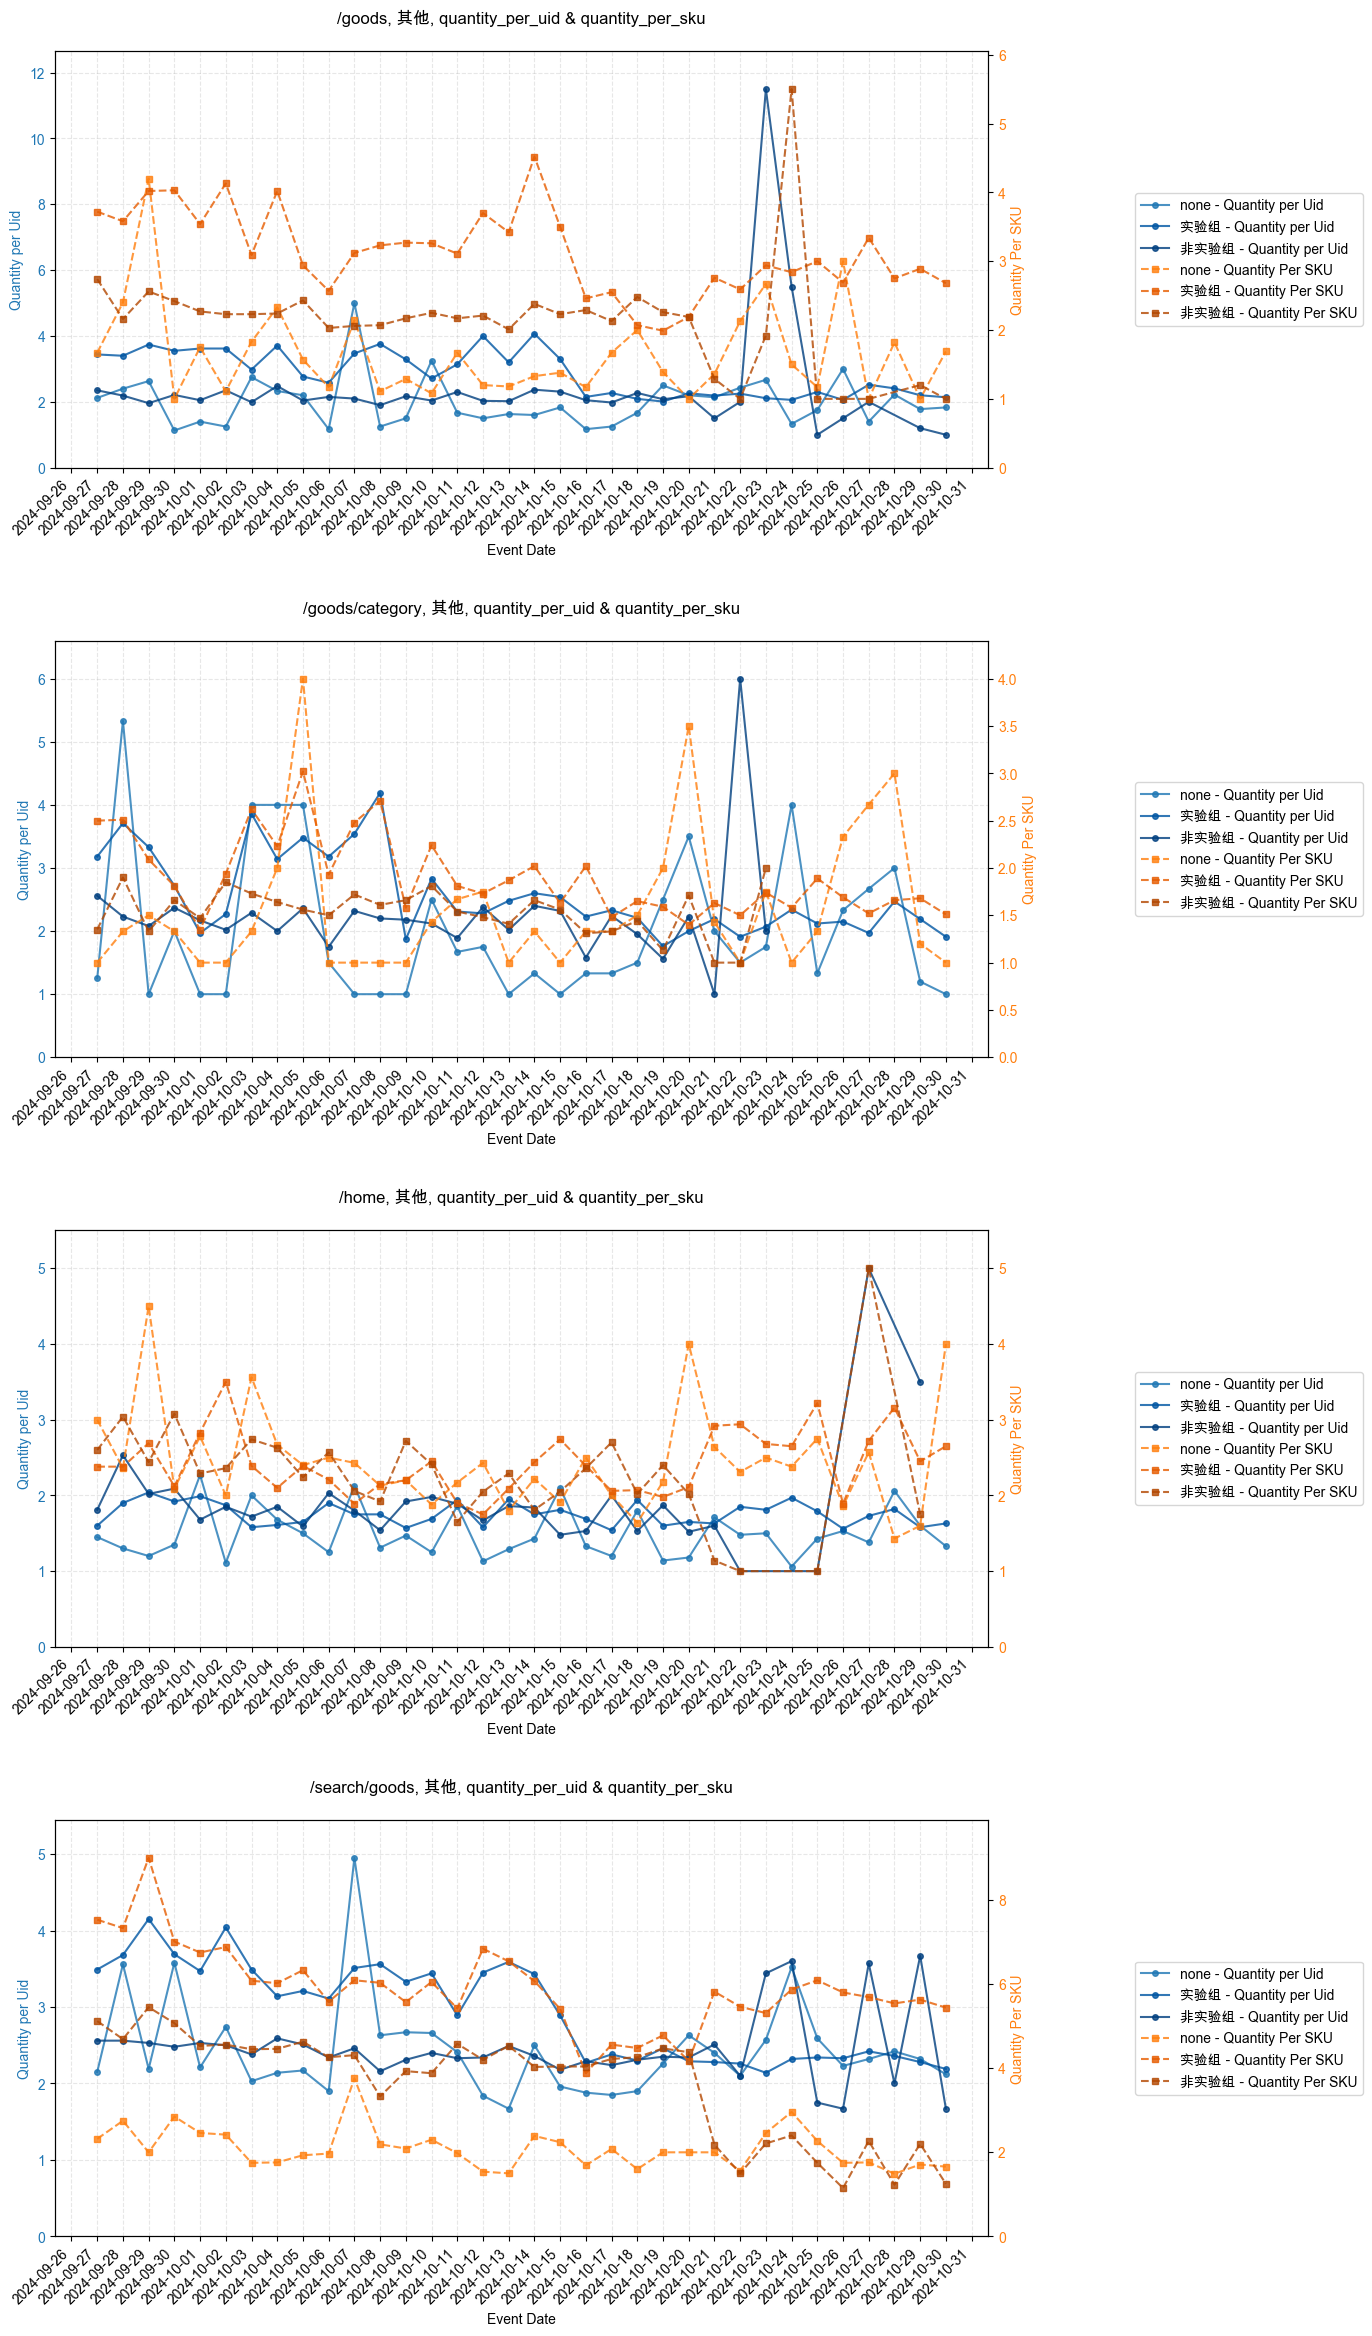

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime

# 过滤需要的页面
filtered_pages = ["/home", "/goods", "/search/goods", "/goods/category"]
filtered_df = daily_add_cart_df[
    (daily_add_cart_df["page_name"].isin(filtered_pages))
    & (daily_add_cart_df["category1"] == "其他")
]

def create_multi_axis_plots(daily_add_cart_df: pd.DataFrame):
    # 设置中文字体
    plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
    plt.rcParams["axes.unicode_minus"] = False

    # 计算需要的子图数量
    num_subplots = len(daily_add_cart_df.groupby(["page_name", "category1"]))

    # 创建足够数量的子图
    fig, axes = plt.subplots(
        nrows=num_subplots, ncols=1, figsize=(12, 6 * num_subplots)
    )
    if num_subplots == 1:
        axes = [axes]  # 确保axes始终是列表

    # 定义颜色系列
    color_series_uid = ["#1f77b4", "#0056a3", "#003f7f", "#002b5c"]  # 更深的蓝色渐变
    color_series_sku = ["#ff7f0e", "#e65c00", "#b34700", "#802b00"]  # 更深的橙色渐变

    for ax, ((page_name, category1), group_df) in zip(
        axes, daily_add_cart_df.groupby(["page_name", "category1"])
    ):
        # 确保日期格式正确
        if not pd.api.types.is_datetime64_any_dtype(group_df["event_date"]):
            group_df["event_date"] = pd.to_datetime(group_df["event_date"])

        # 设置x轴格式
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.xaxis.set_major_locator(mdates.DayLocator())  # 每天都展示

        # 获取quantity_per_uid的最大值，用于设置y轴范围
        max_uid = 0
        max_sku = 0

        # quantity_per_uid 作为第一个y轴
        ax.set_xlabel("Event Date")
        ax.set_ylabel("Quantity per Uid", color=color_series_uid[0])
        lines1 = []

        for idx, (variant, variant_df) in enumerate(group_df.groupby("variant")):
            max_uid = max(max_uid, variant_df["quantity_per_uid"].max())
            (line,) = ax.plot(
                variant_df["event_date"],
                variant_df["quantity_per_uid"],
                label=f"{variant} - Quantity per Uid",
                color=color_series_uid[idx % len(color_series_uid)],
                alpha=0.8,
                marker="o",
                markersize=4,
            )
            lines1.append(line)

        # 设置第一个y轴的范围，从0开始
        ax.set_ylim(bottom=0, top=max_uid * 1.1)  # 顶部留出10%的空间
        ax.tick_params(axis="y", labelcolor=color_series_uid[0])

        # quantity_per_sku 作为第二个y轴
        ax2 = ax.twinx()
        ax2.set_ylabel("Quantity Per SKU", color=color_series_sku[0])
        lines2 = []

        for idx, (variant, variant_df) in enumerate(group_df.groupby("variant")):
            max_sku = max(max_sku, variant_df["quantity_per_sku"].max())
            (line,) = ax2.plot(
                variant_df["event_date"],
                variant_df["quantity_per_sku"],
                label=f"{variant} - Quantity Per SKU",
                linestyle="--",
                color=color_series_sku[idx % len(color_series_sku)],
                alpha=0.8,
                marker="s",
                markersize=4,
            )
            lines2.append(line)

        # 设置第二个y轴的范围，从0开始
        ax2.set_ylim(bottom=0, top=max_sku * 1.1)  # 顶部留出10%的空间
        ax2.tick_params(axis="y", labelcolor=color_series_sku[0])

        # 设置x轴标签旋转
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

        # 合并两个y轴的图例
        lines = lines1 + lines2
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc="center left", bbox_to_anchor=(1.15, 0.5))

        # 添加网格线
        ax.grid(True, linestyle="--", alpha=0.3)

        # 设置标题
        ax.set_title(f"{page_name}, {category1}, quantity_per_uid & quantity_per_sku", pad=20, fontsize=12)

    # 调整整体布局
    plt.tight_layout(pad=3.0)
    fig.subplots_adjust(right=0.85)  # 为图例留出空间

    return fig, axes

# 使用示例:
fig, axes = create_multi_axis_plots(filtered_df)
plt.show()

In [21]:
filtered_df.to_csv(
    f"./data/鲜果-分页面的用户加购明细数据{filtered_df['event_date'].min().split(' ')[0]}~{filtered_df['event_date'].max().split(' ')[0]}.csv",
    index=False,
)